In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Loading the Datasets to the Pandas Data Frame

In [55]:
df = pd.read_csv("books_summary.csv")
df = df.rename(columns={"Unnamed: 0": "index"})

In [9]:

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,     # reproducible
)


In [10]:
train_df

,index,book_name,summaries,categories
5036,5080,Breath,is a fascinating and helpful guide to underst...,mindfulness
3372,3397,Radical Acceptance,teaches how you can become more content and h...,health
4137,4169,The Highly Sensitive Person,is a self-assessment guide and how-to-live te...,communication
283,283,Genius: The Life And Science Of Richard Feynman,tells the story of one the greatest minds in ...,biography
4960,5000,Don Quixote,is a classic novel from 1605 which portraits ...,mindfulness
...,...,...,...,...
466,469,The Bitcoin Standard,uses the history of money and gold to explain...,economics
3092,3116,High-Impact Tools for Teams,aims to combat recurring project-management p...,management
3772,3800,Great By Choice,analyzes what makes the world’s best companie...,business
5191,5235,Less Doing More Living,is based on the assumption that the less you ...,mindfulness


In [11]:
test_df

,index,book_name,summaries,categories
1126,1136,The 5 Love Languages,shows couples how to make their love last by ...,happiness
79,79,The Telomere Effect,shows you how to live healthier and stay youn...,science
3260,3284,Keto Answers,is your go-to guide on how to get started wit...,health
1736,1751,Peak,accumulates everything the pioneer researcher...,productivity
4526,4562,Discipline Is Destiny,is a three-part manual to master and implemen...,work
...,...,...,...,...
927,933,Keep Showing Up,explores the struggles that married couples f...,happiness
4200,4234,The Seven Principles For Making Marriage Work,is a compilation of the best lessons from Joh...,communication
45,45,What Is Life?,compresses a series of lectures given by the n...,science
1729,1744,The Four Agreements,"draws on the long tradition of the Toltecs, a...",productivity


 ### Analysing the Data Distrubution How it is distributed how the data is and how it is split after the train and test data - whether this is balanced data or not

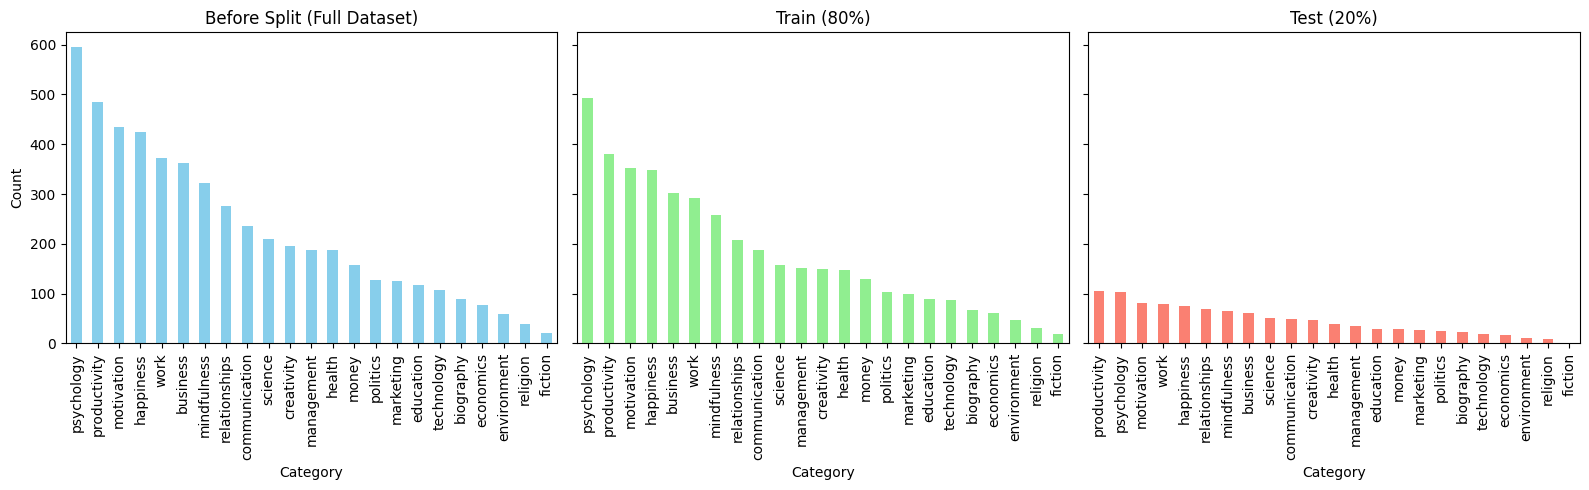

In [14]:
def plot_category_counts(df_full, train_df, test_df):
    fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)

    # Before split
    df_full["categories"].value_counts().plot(kind="bar", ax=axes[0], color="skyblue")
    axes[0].set_title("Before Split (Full Dataset)")
    axes[0].set_ylabel("Count")
    axes[0].set_xlabel("Category")

    # Train split
    train_df["categories"].value_counts().plot(kind="bar", ax=axes[1], color="lightgreen")
    axes[1].set_title("Train (80%)")
    axes[1].set_xlabel("Category")

    # Test split
    test_df["categories"].value_counts().plot(kind="bar", ax=axes[2], color="salmon")
    axes[2].set_title("Test (20%)")
    axes[2].set_xlabel("Category")

    plt.tight_layout()
    plt.show()

plot_category_counts(df, train_df, test_df)


Getting the Stats of the Count of every category

In [15]:
def category_distribution_table(df, train_df, test_df):
    # Counts
    full_counts  = df["categories"].value_counts().sort_index()
    train_counts = train_df["categories"].value_counts().sort_index()
    test_counts  = test_df["categories"].value_counts().sort_index()

    # Build DataFrame
    dist_table = pd.DataFrame({
        "Full_Count": full_counts,
        "Train_Count": train_counts,
        "Test_Count": test_counts
    }).fillna(0).astype(int)

    # Add percentages
    dist_table["Full_%"]  = (dist_table["Full_Count"]  / len(df)       * 100).round(2)
    dist_table["Train_%"] = (dist_table["Train_Count"] / len(train_df) * 100).round(2)
    dist_table["Test_%"]  = (dist_table["Test_Count"]  / len(test_df)  * 100).round(2)

    return dist_table

dist_table = category_distribution_table(df, train_df, test_df)
print(dist_table)


               Full_Count  Train_Count  Test_Count  Full_%  Train_%  Test_%
categories                                                                 
biography              89           67          22    1.71     1.61    2.11
business              363          302          61    6.98     7.26    5.86
communication         236          188          48    4.54     4.52    4.61
creativity            195          149          46    3.75     3.58    4.42
economics              77           60          17    1.48     1.44    1.63
education             118           90          28    2.27     2.16    2.69
environment            58           47          11    1.12     1.13    1.06
fiction                20           19           1    0.38     0.46    0.10
happiness             424          348          76    8.15     8.37    7.30
health                187          148          39    3.60     3.56    3.75
management            187          152          35    3.60     3.65    3.36
marketing   

Checking how much data need to be collected in order to make dataset balanced

In [16]:
data = {
    "Category": [
        "biography","business","communication","creativity","economics",
        "education","environment","fiction","happiness","health",
        "management","marketing","mindfulness","money","motivation",
        "politics","productivity","psychology","relationships","religion",
        "science","technology","work"
    ],
    "Current": [
        89,363,236,195,77,
        118,58,20,424,187,
        187,125,322,157,434,
        127,485,595,275,39,
        209,107,372
    ]
}

df_count = pd.DataFrame(data)

# Find max count (target for balance)
max_count = df_count["Current"].max()

# Calculate needed samples
df_count["Target"] = max_count
df_count["Extra_to_Collect"] = df_count["Target"] - df_count["Current"]

# Sort by largest gap
df_sorted = df_count.sort_values("Extra_to_Collect", ascending=False).reset_index(drop=True)

print(df_sorted)

         Category  Current  Target  Extra_to_Collect
0         fiction       20     595               575
1        religion       39     595               556
2     environment       58     595               537
3       economics       77     595               518
4       biography       89     595               506
5      technology      107     595               488
6       education      118     595               477
7       marketing      125     595               470
8        politics      127     595               468
9           money      157     595               438
10     management      187     595               408
11         health      187     595               408
12     creativity      195     595               400
13        science      209     595               386
14  communication      236     595               359
15  relationships      275     595               320
16    mindfulness      322     595               273
17       business      363     595            

Importing Similar Dataset Called CMU Dataset and Integrating it to the Books Summary Datasets for Getting accurate Results

In [24]:
import pandas as pd
import ast
import re

# ---- 1) Load CMU Book Summary (TSV) ----
cols = ["wiki_id","freebase_id","title","author","pub_date","genres","summary"]
cmu = pd.read_csv("booksummaries.txt", sep="\t", header=None, names=cols, quoting=3, on_bad_lines="skip")

# ---- 2) Parse genre dict strings into a Python list of genre names ----
def parse_genres(g):
    if pd.isna(g):
        return []
    try:
        d = ast.literal_eval(g)  # expects strings like {"id":"Genre name", ...}
        if isinstance(d, dict):
            return [v for v in d.values() if isinstance(v, str)]
    except Exception:
        pass
    return []

cmu["genre_list"] = cmu["genres"].apply(parse_genres)

# ---- 3) Define mapping of detailed genres -> single-word majors ----
# Tweak this mapping to your taxonomy. Keys are CMU genre names.
GENRE_TO_MAJOR = {
    # Fiction umbrellas
    "Science fiction": "Fiction",
    "Speculative fiction": "Fiction",
    "Fantasy": "Fiction",
    "Dark fantasy": "Fiction",
    "Urban fantasy": "Fiction",
    "Horror": "Fiction",
    "Romance novel": "Fiction",
    "Romance": "Fiction",
    "Thriller": "Fiction",
    "Mystery": "Fiction",
    "Detective fiction": "Fiction",
    "Historical novel": "Fiction",
    "Novel": "Fiction",
    "Fiction": "Fiction",
    "Short story": "Fiction",
    "Young adult literature": "Fiction",
    "Children's literature": "Fiction",
    "Adventure novel": "Fiction",
    "Political satire": "Fiction",
    "Satire": "Fiction",
    "Allegory": "Fiction",

    # Non-fiction umbrellas
    "Biography": "Biography",
    "Autobiography": "Biography",
    "Memoir": "Biography",

    "Self-help": "Motivation",
    "Personal development": "Motivation",
    "Productivity": "Productivity",

    "Psychology": "Psychology",
    "Sociology": "Psychology",  # optional

    "Religion": "Religion",
    "Religious text": "Religion",
    "Theology": "Religion",

    "Politics": "Politics",
    "Political philosophy": "Politics",
    "International relations": "Politics",

    "Business": "Business",
    "Management": "Management",
    "Marketing": "Marketing",
    "Economics": "Economics",
    "Finance": "Money",

    "Science": "Science",
    "Popular science": "Science",
    "Technology": "Technology",
    "Computer science": "Technology",
    "Environment": "Environment",

    "Education": "Education",
    "Health": "Health",
    "Medicine": "Health",
    "Relationships": "Relationships",
    "Happiness": "Happiness",
    "Mindfulness": "Mindfulness",
    "Creativity": "Creativity",
    "Communication": "Communication",
    "Work": "Work",
}

# If nothing matches the mapping, compress genre phrase to ONE word (first token)
def fallback_one_word(genre_phrase: str) -> str:
    # keep only letters, split, take first token, title-case
    tokens = re.sub(r"[^A-Za-z\s]", " ", genre_phrase).split()
    return tokens[0].title() if tokens else "Unknown"

# If a book has multiple genres, choose by a priority order of majors
MAJOR_PRIORITY = [
    "Fiction","Biography","Psychology","Religion","Politics","Business","Management",
    "Marketing","Economics","Money","Science","Technology","Environment",
    "Education","Health","Relationships","Happiness","Mindfulness",
    "Creativity","Communication","Productivity","Work","Motivation"
]

def pick_major(genres: list[str]) -> str:
    if not genres:
        return "Unknown"

    # First: try explicit mapping of any genre to a major
    mapped = []
    for g in genres:
        g_norm = g.strip()
        if g_norm in GENRE_TO_MAJOR:
            mapped.append(GENRE_TO_MAJOR[g_norm])

    if mapped:
        # pick the mapped major with highest priority
        for m in MAJOR_PRIORITY:
            if m in mapped:
                return m
        return mapped[0]  # fallback if no priority match

    # Second: if no mapping, compress the first available genre to one word
    return fallback_one_word(genres[0])

cmu["MajorGenre"] = cmu["genre_list"].apply(pick_major)

# ---- 4) Build the final table: Title | Genre | Summary ----
cmu_major = cmu[["title","MajorGenre","summary"]].rename(
    columns={"title":"Title", "MajorGenre":"Genre", "summary":"Summary"}
)

# Optional: drop rows with very short/empty summaries
cmu_major = cmu_major.dropna(subset=["Title","Summary"]).copy()
cmu_major = cmu_major[cmu_major["Summary"].str.strip().str.len() > 0]

# Save if you want
cmu_major.to_csv("cmu_title_genre_summary.csv", index=False)

# Peek
print(cmu_major.head(10))
print("\nCounts by major genre:\n", cmu_major["Genre"].value_counts().head(20))


                                       Title    Genre  \
0                                Animal Farm  Fiction   
1                         A Clockwork Orange  Fiction   
2                                 The Plague  Fiction   
3  An Enquiry Concerning Human Understanding  Unknown   
4                       A Fire Upon the Deep  Fiction   
5             All Quiet on the Western Front      War   
6                       A Wizard of Earthsea  Fiction   
7                         Anyone Can Whistle  Unknown   
8            Blade Runner 3: Replicant Night  Fiction   
9          Blade Runner 2: The Edge of Human  Fiction   

                                             Summary  
0   Old Major, the old boar on the Manor Farm, ca...  
1   Alex, a teenager living in near-future Englan...  
2   The text of The Plague is divided into five p...  
3   The argument of the Enquiry proceeds by a ser...  
4   The novel posits that space around the Milky ...  
5   The book tells the story of Paul Bäume

In [25]:
cmu_major.head()

,Title,Genre,Summary
0,Animal Farm,Fiction,"Old Major, the old boar on the Manor Farm, ca..."
1,A Clockwork Orange,Fiction,"Alex, a teenager living in near-future Englan..."
2,The Plague,Fiction,The text of The Plague is divided into five p...
3,An Enquiry Concerning Human Understanding,Unknown,The argument of the Enquiry proceeds by a ser...
4,A Fire Upon the Deep,Fiction,The novel posits that space around the Milky ...


In [29]:
df_data2 = pd.read_csv("data2.csv")
df_data2 = df_data2.rename(columns={"Unnamed: 0": "index"})

In [30]:
df_data2.head()

,index,Title,Genre,Summary
0,0,Animal Farm,Absurdist,"Old Major, the old boar on the Manor Farm, ca..."
1,1,A Clockwork Orange,Absurdist,"Alex, a teenager living in near-future Englan..."
2,2,The Plague,Albino,The text of The Plague is divided into five p...
3,3,An Enquiry Concerning Human Understanding,Alien,The argument of the Enquiry proceeds by a ser...
4,4,A Fire Upon the Deep,Alternate,The novel posits that space around the Milky ...


In [31]:
need_per_category = {
    "Fiction":575, "Religion":556, "Environment":537, "Economics":518, "Biography":506,
    "Technology":488, "Education":477, "Marketing":470, "Politics":468, "Money":438,
    "Management":408, "Health":408, "Creativity":400, "Science":386, "Communication":359,
    "Relationships":320, "Mindfulness":273, "Business":232, "Work":223, "Happiness":171,
    "Motivation":161, "Productivity":110
}

In [114]:
needed_from_cmu.head()

,Title,Genre,Summary
0,Dawn of the Dragons,Fiction,"Lone Wolf, Kai Grand Master of Sommerlund, ha..."
1,Philosophy in a New Key,Fiction,"""Langer elaborates her thesis in freshly conc..."
2,Are You My Mother?,Fiction,"""Are You My Mother?"" is the story about a hat..."
3,Convergence,Fiction,The book takes place millennia in the future ...
4,Silverwing,Fiction,"Part One Shade, a young Silverwing bat, is co..."


In [77]:
import pandas as pd

# Step 1: Rename df1 columns to match df2 schema (and make lowercase)
df1_renamed = needed_from_cmu.rename(columns={
    "Title": "book_name",
    "Genre": "categories",
    "Summary": "summaries"
})

# Ensure all column names are lowercase
df1_renamed.columns = df1_renamed.columns.str.lower()
df.columns = df.columns.str.lower()

# Step 2: Select only needed columns
df1_final = df1_renamed[["book_name", "categories", "summaries"]]
df2_final = df[["book_name", "categories", "summaries"]]

# Step 3: Normalize categories to lowercase (case-insensitive)
df1_final["categories"] = df1_final["categories"].str.lower()
df2_final["categories"] = df2_final["categories"].str.lower()

# Step 4: Append / concatenate datasets
final_df = pd.concat([df1_final, df2_final], ignore_index=True)

print(final_df.head())
print(final_df["categories"].value_counts().head(10))  # check normalized categories


                 book_name categories  \
0      Dawn of the Dragons    fiction   
1  Philosophy in a New Key    fiction   
2       Are You My Mother?    fiction   
3              Convergence    fiction   
4               Silverwing    fiction   

                                           summaries  
0   Lone Wolf, Kai Grand Master of Sommerlund, ha...  
1   "Langer elaborates her thesis in freshly conc...  
2   "Are You My Mother?" is the story about a hat...  
3   The book takes place millennia in the future ...  
4   Part One Shade, a young Silverwing bat, is co...  
categories
fiction         595
science         595
psychology      595
productivity    485
motivation      438
happiness       424
work            372
business        370
mindfulness     322
biography       285
Name: count, dtype: int64


/tmp/ipython-input-514999575.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_final["categories"] = df2_final["categories"].str.lower()


In [78]:
final_df.to_csv("Final_dataset.csv", index=False)

In [79]:
final_train, final_test = train_test_split(
    final_df,
    test_size=0.20,
    random_state=42,     # reproducible
)

Again analysing the Categories now it was lit imporved and if you  wanna more balanced data can collect more data for accurate results

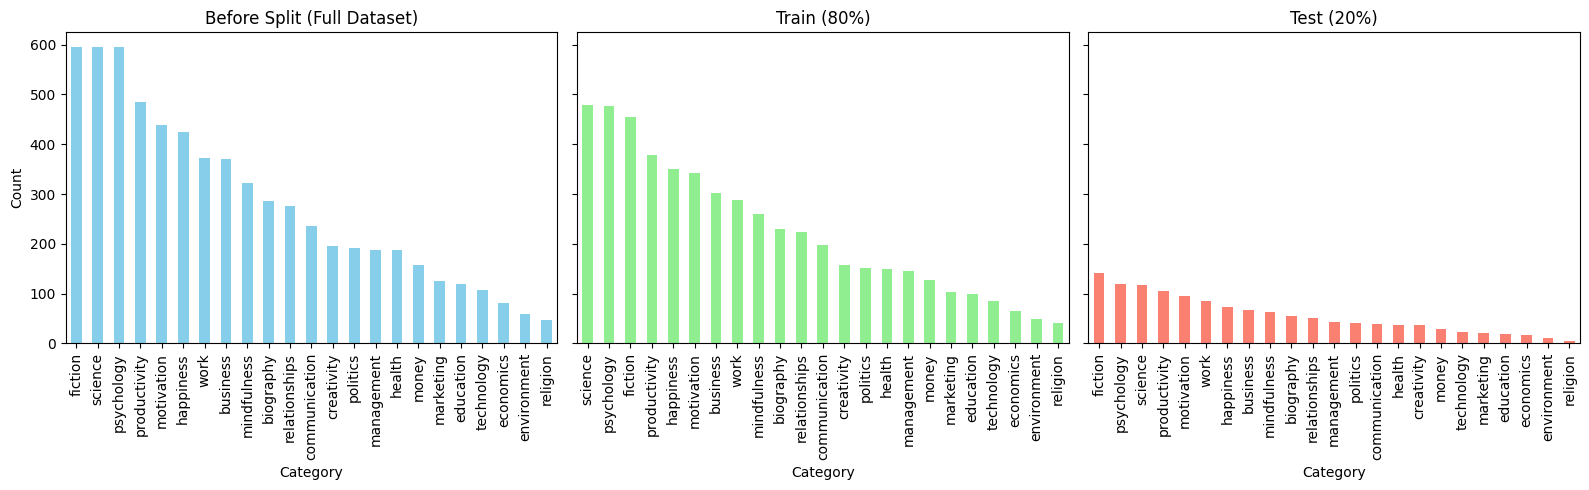

In [80]:
plot_category_counts(final_df, final_train, final_test)

In [82]:
def category_distribution_table(df, train_df, test_df):
    # Counts
    full_counts  = final_df["categories"].value_counts().sort_index()
    train_counts = final_train["categories"].value_counts().sort_index()
    test_counts  = final_test["categories"].value_counts().sort_index()

    # Build DataFrame
    dist_table = pd.DataFrame({
        "Full_Count": full_counts,
        "Train_Count": train_counts,
        "Test_Count": test_counts
    }).fillna(0).astype(int)

    # Add percentages
    dist_table["Full_%"]  = (dist_table["Full_Count"]  / len(final_df)       * 100).round(2)
    dist_table["Train_%"] = (dist_table["Train_Count"] / len(final_train) * 100).round(2)
    dist_table["Test_%"]  = (dist_table["Test_Count"]  / len(final_test)  * 100).round(2)

    return dist_table

dist_table = category_distribution_table(final_df, final_train, final_test)
print(dist_table)


               Full_Count  Train_Count  Test_Count  Full_%  Train_%  Test_%
categories                                                                 
biography             285          230          55    4.42     4.46    4.26
business              370          303          67    5.74     5.88    5.19
communication         236          198          38    3.66     3.84    2.95
creativity            195          158          37    3.03     3.06    2.87
economics              81           65          16    1.26     1.26    1.24
education             119          100          19    1.85     1.94    1.47
environment            58           48          10    0.90     0.93    0.78
fiction               595          454         141    9.23     8.81   10.93
happiness             424          350          74    6.58     6.79    5.74
health                187          150          37    2.90     2.91    2.87
management            187          145          42    2.90     2.81    3.26
marketing   

In [83]:
!pip install transformers datasets


Now Data Preparation For Book recomendation  
Setence-transformers from Hugging face gives the  similarly score and embeddings for the sentences given

In [85]:
!pip install sentence-transformers faiss-cpu pandas numpy scikit-learn


In [86]:
from sentence_transformers import SentenceTransformer
import faiss

You have: book_name, summaries, categories.
You want: a clean catalog you can embed (via SentenceTransformer), index (via FAISS), and query.
Dataset prep ensures:

consistent schema (columns, types, casing)

clean text (no weird whitespace, NaNs)

deduplicated items

standardized categories (optional: multi-label)

reproducibility (splits + saved artifacts)

In [89]:
import pandas as pd
import numpy as np

# Assume you already unified to this schema:
# final_df: ['book_name', 'categories', 'summaries']

df = final_df.copy()

# Normalize column names & types
df.columns = df.columns.str.lower().str.strip()
df['book_name']  = df['book_name'].astype(str).str.strip()
df['categories'] = df['categories'].astype(str).str.lower().str.strip()
df['summaries']  = df['summaries'].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

# Drop rows with missing critical fields
df = df[(df['book_name'] != "") & (df['summaries'] != "")]
df = df.reset_index(drop=True)


In [90]:
# Keep the version with the longest summary (usually most informative)
df = (df.assign(sum_len=df['summaries'].str.len())
        .sort_values('sum_len', ascending=False)
        .drop_duplicates(subset=['book_name'])
        .drop(columns='sum_len')
        .reset_index(drop=True))


3) standardize categories (single-label case)

Why: consistent category vocabulary lets you steer recommendations topically and compute category centroids.

In [91]:
# optional mapping: collapse variants into canonical labels
normalize_map = {
    "bio":"biography", "biz":"business", "sci":"science", "tech":"technology",
    "self-help":"psychology", "self help":"psychology",
}
df['categories'] = df['categories'].replace(normalize_map)

# keep only an allowed whitelist if desired
allowed = {
    "biography","business","communication","creativity","economics","education",
    "environment","fiction","happiness","health","management","marketing",
    "mindfulness","money","motivation","politics","productivity","psychology",
    "relationships","religion","science","technology","work"
}
df = df[df['categories'].isin(allowed)].reset_index(drop=True)


4) multi-label categories (if needed)

If a book can have multiple tags (e.g., "business, management"), normalize and explode.

In [92]:
MULTI = False  # toggle to True if you have multi-tag categories

if MULTI:
    # split by comma or pipe; adjust the split pattern to your data
    df['categories'] = (df['categories']
                        .str.replace(r'\s*,\s*', ',', regex=True)  # clean commas
                        .str.replace(r'\s*\|\s*', '|', regex=True))  # clean pipes
    # produce one row per (book, category)
    df = (df.assign(categories=df['categories'].str.split(','))  # or .str.split('|')
            .explode('categories')
            .reset_index(drop=True))


5) (optional) basic text cleaning

Why: extremely long or empty summaries can hurt or waste compute.

In [93]:
# drop very short summaries (e.g., < 20 chars) and cap very long ones (e.g., 2000 chars)
df = df[df['summaries'].str.len() >= 20].copy()
df['summaries'] = df['summaries'].str.slice(0, 2000)


In [94]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['categories']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)


7) embed summaries & cache

Why: computing embeddings is the slowest step; cache to reuse across sessions and avoid re-encoding.

In [96]:


from sentence_transformers import SentenceTransformer
import numpy as np
import faiss, os

model_name = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

def encode_and_cache(texts, cache_path):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    X = model.encode(texts, normalize_embeddings=True, batch_size=128, show_progress_bar=True)
    np.save(cache_path, X)
    return X

train_emb = encode_and_cache(train_df['summaries'].tolist(), "/content/train_emb.npy")
val_emb   = encode_and_cache(val_df['summaries'].tolist(),   "/content/val_emb.npy")


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

8) build FAISS index

Why: fast ANN search for “more-like-this” and category prototype queries.

In [97]:
d = train_emb.shape[1]
index = faiss.IndexFlatIP(d)        # inner product == cosine (since normalized)
index.add(train_emb.astype('float32'))

# quick lookup
name_to_idx = {n:i for i, n in enumerate(train_df['book_name'])}


In [98]:
cat2vec = {}
for cat, sub in train_df.groupby('categories'):
    vecs = train_emb[sub.index]
    centroid = vecs.mean(axis=0)
    centroid = centroid / (np.linalg.norm(centroid) + 1e-12)
    cat2vec[cat] = centroid.astype('float32')


Writing Helper functions for the Recommending based on Category , Context an well as hybrid

In [101]:
import pandas as pd
import numpy as np

def recommend_by_category(category, top_k=15):
    cat = category.lower().strip()
    if cat not in cat2vec:
        raise ValueError(f"Unknown category: {category}")
    q = cat2vec[cat][None, :]
    D, I = index.search(q, top_k*3)  # oversample
    cand = train_df.iloc[I[0]].copy()
    cand["sim_cat"] = D[0]
    cand = cand[cand["categories"] == cat]
    return cand.head(top_k)[["book_name","categories","sim_cat","summaries"]].reset_index(drop=True)

def recommend_similar_to(title, top_k=10):
    if title not in name_to_idx:
        raise ValueError(f"Book not found in train set: {title}")
    q = train_emb[name_to_idx[title]][None, :]
    D, I = index.search(q, top_k+1)
    cand = train_df.iloc[I[0]].copy()
    cand["sim"] = D[0]
    cand = cand[cand["book_name"] != title]
    return cand.head(top_k)[["book_name","categories","sim","summaries"]].reset_index(drop=True)

def recommend_hybrid(seed_title=None, category=None, top_k=200, final_k=20, alpha=0.7, lam=0.3):
    """
    alpha: weight when mixing seed and category vectors (if both provided).
    lam:   weight for category bonus in final score.
    """
    q_sim = None
    if seed_title:
        if seed_title not in name_to_idx:
            raise ValueError(f"Book not found: {seed_title}")
        q_sim = train_emb[name_to_idx[seed_title]][None, :]

    q_cat = None
    cat = None
    if category:
        cat = category.lower().strip()
        if cat not in cat2vec:
            raise ValueError(f"Unknown category: {category}")
        q_cat = cat2vec[cat][None, :]

    if q_sim is not None and q_cat is not None:
        q = (alpha * q_sim + (1 - alpha) * q_cat)
        q = q / (np.linalg.norm(q) + 1e-12)
    elif q_sim is not None:
        q = q_sim
    elif q_cat is not None:
        q = q_cat
    else:
        mean_vec = np.mean(np.stack(list(cat2vec.values())), axis=0)
        q = mean_vec[None, :] / (np.linalg.norm(mean_vec) + 1e-12)

    D, I = index.search(q.astype("float32"), top_k)
    cand = train_df.iloc[I[0]].copy()
    cand["sim_content"] = D[0]

    if category:
        cand["cat_bonus"] = (cand["categories"] == cat).astype(float)
    else:
        # topical fit = max cosine to any category centroid
        def max_cat_cos(idx):
            v = train_emb[idx]
            return max(float(np.dot(v, cvec)) for cvec in cat2vec.values())
        cand["cat_bonus"] = [max_cat_cos(i) for i in I[0]]

    cand["score"] = (1 - lam) * cand["sim_content"] + lam * cand["cat_bonus"]

    if seed_title:
        cand = cand[cand["book_name"] != seed_title]

    return cand.sort_values("score", ascending=False).head(final_k)[
        ["book_name","categories","score","sim_content","cat_bonus","summaries"]
    ].reset_index(drop=True)


In [100]:
train_df.to_parquet("/content/train_catalog.parquet", index=False)
val_df.to_parquet("/content/val_catalog.parquet", index=False)
faiss.write_index(index, "/content/faiss_flatip.index")
np.save("/content/cat2vec_keys.npy", np.array(list(cat2vec.keys()), dtype=object))
np.save("/content/cat2vec_vals.npy", np.stack(list(cat2vec.values())))


In [102]:
# pick any existing values
sample_cat   = train_df["categories"].iloc[0]
sample_title = train_df["book_name"].iloc[0]

print("Top in category:", sample_cat)
display(recommend_by_category(sample_cat, top_k=10))

print("\nSimilar to:", sample_title)
display(recommend_similar_to(sample_title, top_k=10))

print("\nHybrid sample:")
display(recommend_hybrid(seed_title=sample_title, category=sample_cat, final_k=10))


Top in category: motivation


,book_name,categories,sim_cat,summaries
0,What I Know For Sure,motivation,0.756160,encourages you to create the life you want by ...
1,The Motivation Manifesto,motivation,0.749099,explores how we can find purpose and meaningfu...
2,Start,motivation,0.735726,shows you how you can flip the switch of your ...
3,The Slight Edge,motivation,0.721631,"outlines the importance of doing small, little..."
4,Maximize Your Potential,motivation,0.714415,shows you how to make your work life one that’...
5,Resilience,motivation,0.697565,"will help you find joy in self-transformation,..."



Similar to: The Big Leap


,book_name,categories,sim,summaries
0,Reinvent Yourself,technology,0.649778,is a template for how to best adapt in a world...
1,As A Man Thinketh,psychology,0.615768,"is an essay and self-help classic, which argue..."
2,Everyday Zen,environment,0.614729,explains the philosophy of a meaningful life a...
3,Choose Yourself,motivation,0.603184,is a call to give up traditional career paths ...
4,The 15 Invaluable Laws Of Growth,productivity,0.594542,will inspire you to get up and improve your li...
5,Maximize Your Potential,motivation,0.591352,shows you how to make your work life one that’...
6,The Road Less Traveled,science,0.575217,"is a spiritual classic, combining scientific a..."
7,Real Help,relationships,0.567705,offers a hands-on approach to improving your l...
8,Your Best Year Ever,health,0.566943,gives powerful inspiration to change your life...
9,How Will You Measure Your Life,happiness,0.553502,shows you how to sustain motivation at work an...



Hybrid sample:


,book_name,categories,score,sim_content,cat_bonus,summaries
0,Maximize Your Potential,motivation,0.772539,0.675056,1.0,shows you how to make your work life one that’...
1,Choose Yourself,motivation,0.763899,0.662713,1.0,is a call to give up traditional career paths ...
2,What I Know For Sure,motivation,0.743592,0.633703,1.0,encourages you to create the life you want by ...
3,The Motivation Manifesto,motivation,0.738219,0.626027,1.0,explores how we can find purpose and meaningfu...
4,Resilience,motivation,0.728798,0.612569,1.0,"will help you find joy in self-transformation,..."
5,The Slight Edge,motivation,0.726531,0.609329,1.0,"outlines the importance of doing small, little..."
6,The Practice of Groundedness,motivation,0.725931,0.608473,1.0,provides a more grounded way of living by elim...
7,Start,motivation,0.721271,0.601816,1.0,shows you how you can flip the switch of your ...
8,Getting COMFY,motivation,0.712750,0.589643,1.0,will show you how to improve each day of your ...
9,The Energy Bus,motivation,0.700226,0.571752,1.0,is a fable that will help you create positive ...


In [103]:
def mmr_select(indices, embeddings, lambda_mmr=0.5, k=10):
    """
    indices: iterable of candidate row indices (into train_df)
    embeddings: numpy array for all train items (train_emb)
    """
    indices = list(indices)
    if len(indices) <= k:
        return indices

    selected = [indices[0]]
    cand = set(indices[1:])

    def cos(i, j):
        return float(np.dot(embeddings[i], embeddings[j]))

    # use the first candidate as a proxy to query relevance; you can pass a true query vector if available
    q_anchor = indices[0]

    while len(selected) < k and cand:
        best_i, best_score = None, -1e9
        for i in cand:
            relevance = cos(i, q_anchor)
            diversity = max(cos(i, s) for s in selected)
            score = lambda_mmr * relevance - (1 - lambda_mmr) * diversity
            if score > best_score:
                best_i, best_score = i, score
        selected.append(best_i); cand.remove(best_i)

    return selected


In [104]:
import faiss, numpy as np

train_df.to_parquet("/content/train_catalog.parquet", index=False)
val_df.to_parquet("/content/val_catalog.parquet", index=False)
faiss.write_index(index, "/content/faiss_flatip.index")

# save category prototypes
np.save("/content/cat2vec_keys.npy", np.array(list(cat2vec.keys()), dtype=object))
np.save("/content/cat2vec_vals.npy", np.stack(list(cat2vec.values())))

print("Saved:\n- /content/train_catalog.parquet\n- /content/val_catalog.parquet\n- /content/faiss_flatip.index\n- /content/cat2vec_{keys,vals}.npy")


Saved:
- /content/train_catalog.parquet
- /content/val_catalog.parquet
- /content/faiss_flatip.index
- /content/cat2vec_{keys,vals}.npy


In [105]:
import pandas as pd
import numpy as np

def split_cats(s: str):
    s = str(s).lower().strip()
    if "|" in s:
        parts = [p.strip() for p in s.split("|") if p.strip()]
    elif "," in s:
        parts = [p.strip() for p in s.split(",") if p.strip()]
    else:
        parts = [s] if s else []
    return parts

# Create a list column for categories
train_df = train_df.copy()
train_df["cats_list"] = train_df["categories"].apply(split_cats)

# Build per-category centroids from multi-label assignments
all_cats = sorted({c for lst in train_df["cats_list"] for c in lst})
cat2vec = {}
for cat in all_cats:
    idxs = train_df.index[train_df["cats_list"].map(lambda lst: cat in lst)].to_list()
    if not idxs:
        continue
    vecs = train_emb[idxs]
    c = vecs.mean(axis=0)
    c = c / (np.linalg.norm(c) + 1e-12)
    cat2vec[cat] = c.astype("float32")

len(cat2vec), list(cat2vec)[:8]


(23,
 ['biography',
  'business',
  'communication',
  'creativity',
  'economics',
  'education',
  'environment',
  'fiction'])

In [106]:
def mmr_select(indices, embeddings, lambda_mmr=0.5, k=10):
    """
    indices: iterable of candidate row indices into train_df
    embeddings: numpy array aligned with train_df (e.g., train_emb)
    """
    indices = list(indices)
    if len(indices) <= k:
        return indices

    selected = [indices[0]]
    cand = set(indices[1:])

    def cos(i, j):
        return float(np.dot(embeddings[i], embeddings[j]))

    # Use first candidate as a proxy anchor (works fine for content-based search)
    q_anchor = indices[0]

    while len(selected) < k and cand:
        best_i, best_score = None, -1e9
        for i in cand:
            relevance = cos(i, q_anchor)
            diversity = max(cos(i, s) for s in selected)
            score = lambda_mmr * relevance - (1 - lambda_mmr) * diversity
            if score > best_score:
                best_i, best_score = i, score
        selected.append(best_i); cand.remove(best_i)

    return selected


In [107]:
import numpy as np

def recommend_by_category(category, top_k=15, use_mlr=True, use_mmr=False, mmr_lambda=0.5):
    cat = category.lower().strip()
    if cat not in cat2vec:
        raise ValueError(f"Unknown category: {category}")
    q = cat2vec[cat][None, :]
    D, I = index.search(q, top_k * 5)  # oversample
    cand = train_df.iloc[I[0]].copy()
    cand["sim_cat"] = D[0]
    # keep items that include this category (multi-label aware)
    cand = cand[cand["cats_list"].map(lambda lst: cat in lst)]
    # Add original index for MMR selection
    cand["idx"] = cand.index.astype(int)

    if use_mmr and len(cand) > 0:
        picked = mmr_select(cand["idx"].tolist(), train_emb, lambda_mmr=mmr_lambda, k=top_k)
        cand = cand.set_index("idx").loc[picked].reset_index()
    else:
        cand = cand.head(top_k)

    return cand[["book_name","categories","sim_cat","summaries"]].reset_index(drop=True)

def recommend_similar_to(title, top_k=10, use_mmr=False, mmr_lambda=0.5):
    if title not in name_to_idx:
        raise ValueError(f"Book not found: {title}")
    q = train_emb[name_to_idx[title]][None, :]
    D, I = index.search(q, top_k + 50)   # oversample a bit
    cand = train_df.iloc[I[0]].copy()
    cand["sim"] = D[0]
    cand = cand[cand["book_name"] != title]
    cand["idx"] = cand.index.astype(int)

    if use_mmr and len(cand) > 0:
        picked = mmr_select(cand["idx"].tolist(), train_emb, lambda_mmr=mmr_lambda, k=top_k)
        cand = cand.set_index("idx").loc[picked].reset_index()
    else:
        cand = cand.head(top_k)

    return cand[["book_name","categories","sim","summaries"]].reset_index(drop=True)

def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b: return 0.0
    return len(a & b) / max(1, len(a | b))

def recommend_hybrid(seed_title=None, prefer_categories=None, top_k=200, final_k=20,
                     alpha=0.7, lam=0.3, use_mmr=False, mmr_lambda=0.5):
    """
    alpha: mix for seed-vs-category query vector (if both provided)
    lam:   final score weight for category_bonus (Jaccard)
    prefer_categories: list[str] of preferred categories (multi-label aware)
    """
    # Build query vector from seed and/or category prototypes
    q_sim = None
    if seed_title:
        if seed_title not in name_to_idx:
            raise ValueError(f"Book not found: {seed_title}")
        q_sim = train_emb[name_to_idx[seed_title]][None, :]

    q_cat = None
    if prefer_categories:
        # average all chosen category centroids
        centroids = [cat2vec[c.lower()] for c in prefer_categories if c.lower() in cat2vec]
        if centroids:
            c = np.mean(np.stack(centroids), axis=0)
            q_cat = (c / (np.linalg.norm(c) + 1e-12))[None, :]

    if q_sim is not None and q_cat is not None:
        q = (alpha * q_sim + (1 - alpha) * q_cat)
        q = q / (np.linalg.norm(q) + 1e-12)
    elif q_sim is not None:
        q = q_sim
    elif q_cat is not None:
        q = q_cat
    else:
        # cold query: centroid of centroids
        mean_vec = np.mean(np.stack(list(cat2vec.values())), axis=0)
        q = mean_vec[None, :] / (np.linalg.norm(mean_vec) + 1e-12)

    D, I = index.search(q.astype("float32"), top_k)
    cand = train_df.iloc[I[0]].copy()
    cand["sim_content"] = D[0]
    cand["idx"] = cand.index.astype(int)

    # Category bonus via Jaccard with preferred set or seed's cats_list
    if prefer_categories:
        pref_set = {c.lower() for c in prefer_categories}
        cand["cat_bonus"] = cand["cats_list"].map(lambda lst: jaccard(lst, pref_set))
    elif seed_title:
        seed_cats = train_df.loc[name_to_idx[seed_title], "cats_list"]
        cand["cat_bonus"] = cand["cats_list"].map(lambda lst: jaccard(lst, seed_cats))
    else:
        # If truly nothing, give small general topical fit via max centroid cosine
        def max_cat_cos(idx):
            v = train_emb[idx]
            return max(float(np.dot(v, cvec)) for cvec in cat2vec.values())
        cand["cat_bonus"] = [max_cat_cos(i) for i in I[0]]

    cand["score"] = (1 - lam) * cand["sim_content"] + lam * cand["cat_bonus"]

    # Optional MMR on top candidates
    cand = cand.sort_values("score", ascending=False)
    if use_mmr and len(cand) > 0:
        picked = mmr_select(cand["idx"].tolist(), train_emb, lambda_mmr=mmr_lambda, k=final_k)
        cand = cand.set_index("idx").loc[picked].reset_index()
    else:
        cand = cand.head(final_k)

    return cand[["book_name","categories","score","sim_content","cat_bonus","summaries"]].reset_index(drop=True)


Built an UI for Recommendation Models

In [108]:
!pip -q install gradio

import gradio as gr

def ui_by_category(category, k):
    try:
        out = recommend_by_category(category, top_k=int(k), use_mmr=True, mmr_lambda=0.5)
        return out
    except Exception as e:
        return pd.DataFrame({"error":[str(e)]})

def ui_similar(title, k):
    try:
        out = recommend_similar_to(title, top_k=int(k), use_mmr=True, mmr_lambda=0.5)
        return out
    except Exception as e:
        return pd.DataFrame({"error":[str(e)]})

def ui_hybrid(seed_title, categories_csv, k, alpha, lam):
    try:
        prefs = [c.strip() for c in str(categories_csv).split(",") if c.strip()] if categories_csv else None
        out = recommend_hybrid(
            seed_title=seed_title if seed_title else None,
            prefer_categories=prefs,
            final_k=int(k),
            alpha=float(alpha),
            lam=float(lam),
            use_mmr=True,
            mmr_lambda=0.5
        )
        return out
    except Exception as e:
        return pd.DataFrame({"error":[str(e)]})

with gr.Blocks() as demo:
    gr.Markdown("## 📚 Book Recommender — Cold Start (Content-Based + FAISS)")

    with gr.Tab("By Category"):
        cat_in = gr.Textbox(label="Category (e.g., psychology)")
        k1 = gr.Slider(5, 50, value=15, step=1, label="Top K")
        btn1 = gr.Button("Recommend")
        out1 = gr.Dataframe(label="Results")
        btn1.click(ui_by_category, inputs=[cat_in, k1], outputs=out1)

    with gr.Tab("Similar to Title"):
        title_in = gr.Textbox(label="Book Title (must exist in train set)")
        k2 = gr.Slider(5, 50, value=10, step=1, label="Top K")
        btn2 = gr.Button("Find Similar")
        out2 = gr.Dataframe(label="Results")
        btn2.click(ui_similar, inputs=[title_in, k2], outputs=out2)

    with gr.Tab("Hybrid (Seed + Categories)"):
        seed_in = gr.Textbox(label="Seed Title (optional)")
        prefs_in = gr.Textbox(label="Preferred Categories (comma-separated, optional)")
        k3 = gr.Slider(5, 50, value=15, step=1, label="Top K")
        alpha = gr.Slider(0.0, 1.0, value=0.7, step=0.05, label="alpha (seed vs category mix)")
        lam = gr.Slider(0.0, 1.0, value=0.3, step=0.05, label="lambda (category bonus weight)")
        btn3 = gr.Button("Hybrid Recommend")
        out3 = gr.Dataframe(label="Results")
        btn3.click(ui_hybrid, inputs=[seed_in, prefs_in, k3, alpha, lam], outputs=out3)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f31e1fbf4f2ef8fc2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Trying to Improve the Similarity scores and Recommendation Models

In [109]:
import itertools, numpy as np, pandas as pd

def category_at_k(k=10, sample_n=300):
    rng = np.random.default_rng(42)
    idxs = rng.choice(len(train_df), size=min(sample_n, len(train_df)), replace=False)
    hits = []
    for i in idxs:
        seed = train_df.iloc[i]["book_name"]
        seed_cats = set(train_df.iloc[i]["cats_list"])
        try:
            recs = recommend_similar_to(seed, top_k=k, use_mmr=False)
        except:
            continue
        # success if at least one overlapping category
        overlap = recs["book_name"].map(
            lambda bn: len(seed_cats & set(train_df.loc[train_df["book_name"]==bn, "cats_list"].iloc[0])) > 0
        )
        hits.append(overlap.mean())  # fraction of top-k sharing a category
    return float(np.mean(hits)) if hits else 0.0

def intra_list_similarity(recs_df):
    # average pairwise cosine similarity among recommended items
    idxs = train_df[train_df["book_name"].isin(recs_df["book_name"])].index.tolist()
    if len(idxs) < 2: return 0.0
    pairs = list(itertools.combinations(idxs, 2))
    sims = [float(np.dot(train_emb[i], train_emb[j])) for i,j in pairs]
    return float(np.mean(sims))

def evaluate_quick(k=10, sample_n=100):
    rng = np.random.default_rng(0)
    seeds = rng.choice(train_df["book_name"], size=min(sample_n, len(train_df)), replace=False)
    ils_vals, cov_items = [], set()
    for seed in seeds:
        try:
            recs = recommend_similar_to(seed, top_k=k, use_mmr=True, mmr_lambda=0.5)
        except:
            continue
        ils_vals.append(intra_list_similarity(recs))
        cov_items.update(recs["book_name"].tolist())
    metrics = {
        "Category@K (avg fraction overlap)": category_at_k(k=k, sample_n=sample_n),
        "Intra-List Similarity (lower=more diverse)": float(np.mean(ils_vals)) if ils_vals else None,
        "Coverage@K (unique recs / catalog)": len(cov_items) / max(1, len(train_df))
    }
    return metrics

metrics = evaluate_quick(k=10, sample_n=200)
metrics


{'Category@K (avg fraction overlap)': 0.293,
 'Intra-List Similarity (lower=more diverse)': 0.35570394383391574,
 'Coverage@K (unique recs / catalog)': 0.4751131221719457}

In [110]:
from sentence_transformers import SentenceTransformer
import numpy as np, os

# 1) Use a stronger model (slower but better semantics)
model_name = "sentence-transformers/all-mpnet-base-v2"   # upgrade from MiniLM
st_model = SentenceTransformer(model_name)

# 2) Concatenate title + summary (helps disambiguate)
def make_text(row):
    return f"{row['book_name']} [CATEGORY: {row['categories']}] — {row['summaries']}"

train_texts = train_df.apply(make_text, axis=1).tolist()

def encode_and_cache(texts, cache_path):
    if os.path.exists(cache_path):
        return np.load(cache_path)
    X = st_model.encode(texts, normalize_embeddings=True, batch_size=64, show_progress_bar=True)
    np.save(cache_path, X)
    return X

train_emb = encode_and_cache(train_texts, "/content/train_emb_mpnet.npy")

# rebuild FAISS index with new embeddings
import faiss
d = train_emb.shape[1]
index = faiss.IndexFlatIP(d)
index.add(train_emb.astype("float32"))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

In [111]:
# assumes you still have train_df['cats_list'] (or create it with your split function)
def jaccard(a, b):
    a, b = set(a), set(b)
    return 0.0 if (not a and not b) else len(a & b) / max(1, len(a | b))

def rec_similar_with_cat(title, top_k=10, lam=0.25, use_mmr=True, mmr_lambda=0.5):
    if title not in name_to_idx:
        raise ValueError("title not found")
    q = train_emb[name_to_idx[title]][None, :]
    D, I = index.search(q, top_k + 100)  # oversample
    cand = train_df.iloc[I[0]].copy()
    cand["sim"] = D[0]
    seed_cats = train_df.loc[name_to_idx[title], "cats_list"]

    # category bonus via Jaccard
    cand["cat_bonus"] = cand["cats_list"].map(lambda lst: jaccard(lst, seed_cats))
    cand["score"] = (1 - lam) * cand["sim"] + lam * cand["cat_bonus"]
    cand = cand[cand["book_name"] != title].copy()
    cand["idx"] = cand.index.astype(int)

    if use_mmr and len(cand) > 0:
        picked = mmr_select(cand["idx"].tolist(), train_emb, lambda_mmr=mmr_lambda, k=top_k)
        cand = cand.set_index("idx").loc[picked].reset_index()
    else:
        cand = cand.nlargest(top_k, "score")

    return cand[["book_name","categories","score","sim","cat_bonus","summaries"]]


In [112]:
def grid_tune(k=10, sample_n=150, lam_list=(0.2,0.25,0.3), mmr_list=(0.3,0.5,0.7)):
    import numpy as np
    rng = np.random.default_rng(0)
    seeds = rng.choice(train_df["book_name"], size=min(sample_n, len(train_df)), replace=False)
    best = None

    def cat_at_k_for_seed(seed, k, lam, mmr_l):
        try:
            recs = rec_similar_with_cat(seed, top_k=k, lam=lam, use_mmr=True, mmr_lambda=mmr_l)
        except:
            return None, None
        # overlap with seed categories
        seed_cats = set(train_df.loc[name_to_idx[seed], "cats_list"])
        overlaps = []
        for bn in recs["book_name"]:
            cats = train_df.loc[train_df["book_name"]==bn, "cats_list"].iloc[0]
            overlaps.append(len(seed_cats & set(cats)) > 0)
        # diversity
        idxs = train_df[train_df["book_name"].isin(recs["book_name"])].index.tolist()
        ils = 0.0
        if len(idxs) >= 2:
            sims = []
            for i in range(len(idxs)-1):
                for j in range(i+1, len(idxs)):
                    sims.append(float(np.dot(train_emb[idxs[i]], train_emb[idxs[j]])))
            ils = float(np.mean(sims))
        return np.mean(overlaps), ils

    for lam in lam_list:
        for mmr_l in mmr_list:
            cats, ils, seen, cov = [], [], set(), 0
            for seed in seeds:
                c, d = cat_at_k_for_seed(seed, k, lam, mmr_l)
                if c is None:
                    continue
                cats.append(c); ils.append(d)
            score = (np.mean(cats) if cats else 0) - 0.15*(np.mean(ils) if ils else 0)  # prefer higher cat@K, lower ILS
            cand = {"lam":lam, "mmr_lambda":mmr_l,
                    "Category@K": float(np.mean(cats) if cats else 0),
                    "IntraListSim": float(np.mean(ils) if ils else 0),
                    "score": score}
            best = cand if (best is None or cand["score"]>best["score"]) else best
    best

best_params = grid_tune(k=10)
best_params


In [113]:
metrics = evaluate_quick(k=10, sample_n=200)  # reuse your earlier evaluate_quick
metrics


{'Category@K (avg fraction overlap)': 0.3475,
 'Intra-List Similarity (lower=more diverse)': 0.34672185763033725,
 'Coverage@K (unique recs / catalog)': 0.4497737556561086}